# 01 — Data Acquisition & Quality Assessment

Downloads all data from the [Anthropic Economic Index](https://huggingface.co/datasets/Anthropic/EconomicIndex),
along with O\*NET occupational data and BLS employment statistics.

**Critical finding:** The raw data covers 633 occupations, but only ~320 have
sufficient data quality for reliable analysis. The other half are noise — occupations
like "Dancers" with 17 conversations and 1 matched task.

In [1]:
import sys
sys.path.insert(0, "..")

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import (
    download_all, load_onet_tasks, load_collaboration_by_task,
    load_unified_release, load_wage_data, load_job_exposure,
    build_occupation_panel, _build_task_to_soc, RELEASE_FILES,
)

logging.basicConfig(level=logging.INFO)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150

In [2]:
paths = download_all()
print(f"Downloaded {len(paths)}/{len(RELEASE_FILES)} files")

Downloaded 19/19 files


## Data coverage: how much of the labor market is actually represented?

The AEI classifies Claude conversations by O\*NET task. But not every task in
an occupation appears in Claude conversations. **This is the critical quality question.**

In [3]:
onet = load_onet_tasks()
collab = load_collaboration_by_task()
task_to_soc = _build_task_to_soc()

aei_tasks = set(collab['task_name'].str.lower().str.strip())
task_to_soc_copy = task_to_soc.copy()
task_to_soc_copy['in_aei'] = task_to_soc_copy['task_name'].isin(aei_tasks)

coverage = (
    task_to_soc_copy.groupby('soc_code')
    .agg(total_tasks=('task_name', 'nunique'), matched_tasks=('in_aei', 'sum'))
    .reset_index()
)
coverage['coverage_pct'] = coverage['matched_tasks'] / coverage['total_tasks']

print(f"O*NET tasks: {onet['task'].nunique():,}")
print(f"Tasks in AEI data: {len(collab):,}")
print(f"\nTask coverage per occupation:")
print(f"  Median: {coverage['coverage_pct'].median():.0%}")
print(f"  <10% coverage: {(coverage['coverage_pct'] < 0.1).sum()} occupations")
print(f"  <25% coverage: {(coverage['coverage_pct'] < 0.25).sum()} occupations")
print(f"  >50% coverage: {(coverage['coverage_pct'] > 0.5).sum()} occupations")

O*NET tasks: 18,429
Tasks in AEI data: 3,364

Task coverage per occupation:
  Median: 13%
  <10% coverage: 344 occupations
  <25% coverage: 526 occupations
  >50% coverage: 71 occupations


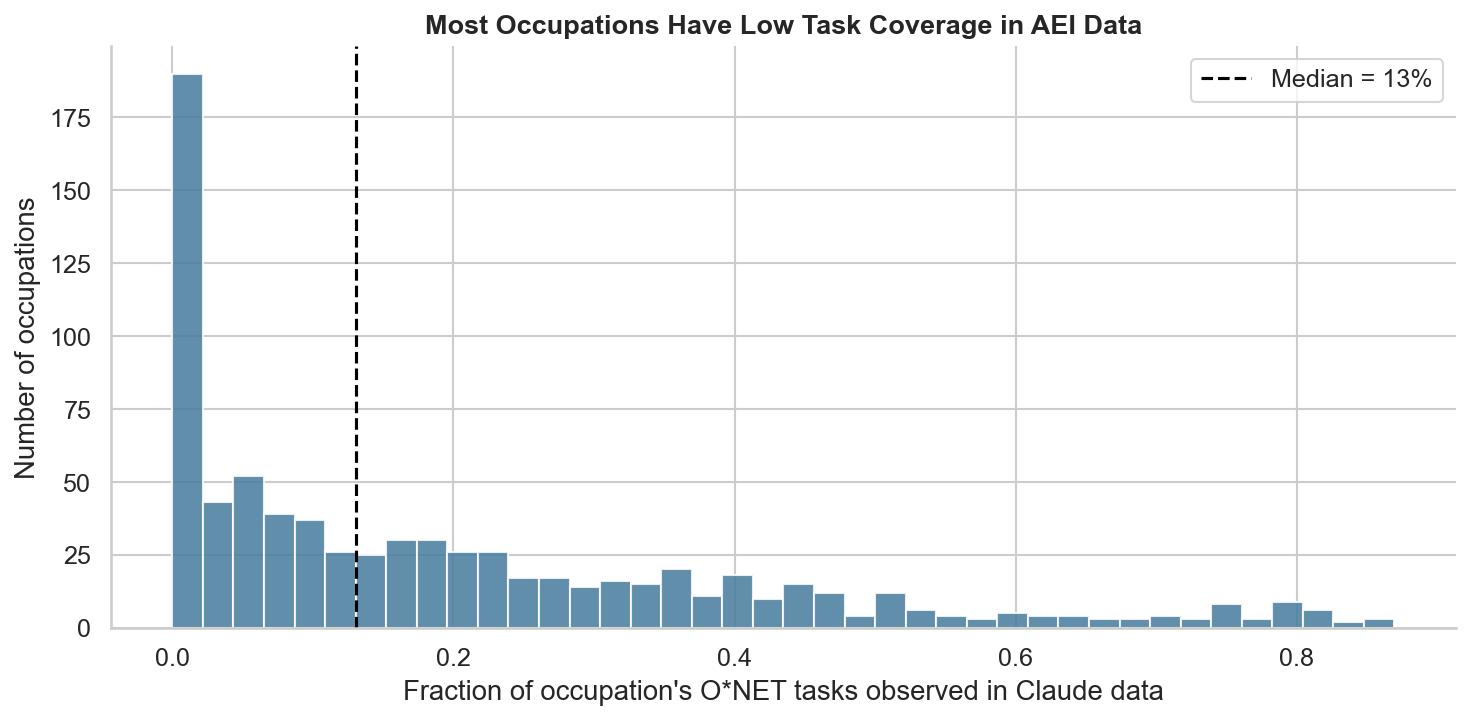

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(coverage['coverage_pct'], bins=40, color='#457B9D', alpha=0.85, edgecolor='white')
ax.axvline(coverage['coverage_pct'].median(), color='black', linestyle='--', linewidth=1.5,
           label=f"Median = {coverage['coverage_pct'].median():.0%}")
ax.set_xlabel("Fraction of occupation's O*NET tasks observed in Claude data")
ax.set_ylabel('Number of occupations')
ax.set_title('Most Occupations Have Low Task Coverage in AEI Data', fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../figures/01_task_coverage.png', bbox_inches='tight')
plt.show()

## Quality filtering

Three filters to keep only occupations with reliable data:
1. **>=200 conversations** — below this, collaboration modes are noisy
2. **>=3 matched tasks** — a single task is not representative
3. **>=3 releases** — need temporal coverage to measure velocity

In [5]:
from src.features import build_feature_matrix

unfiltered = build_feature_matrix(apply_quality_filter=False)
filtered = build_feature_matrix(apply_quality_filter=True)

print(f"Before filtering: {len(unfiltered)} occupations")
print(f"After filtering:  {len(filtered)} occupations ({len(filtered)/len(unfiltered):.0%})")
print(f"\nRemoved {len(unfiltered) - len(filtered)} occupations with insufficient data.")
print(f"Example removed: 'Dancers' (17 convs, 1 task), 'Fish and Game Wardens' (16 convs).")

INFO:src.features:Quality filter: 633 → 319 occupations (removed 314 with insufficient data)


Before filtering: 633 occupations
After filtering:  319 occupations (50%)

Removed 314 occupations with insufficient data.
Example removed: 'Dancers' (17 convs, 1 task), 'Fish and Game Wardens' (16 convs).


## API vs. Claude.ai: two fundamentally different usage patterns

This is arguably the most important split in the data. API usage (programmatic,
often automated pipelines) is dramatically more automative than interactive Claude.ai use.

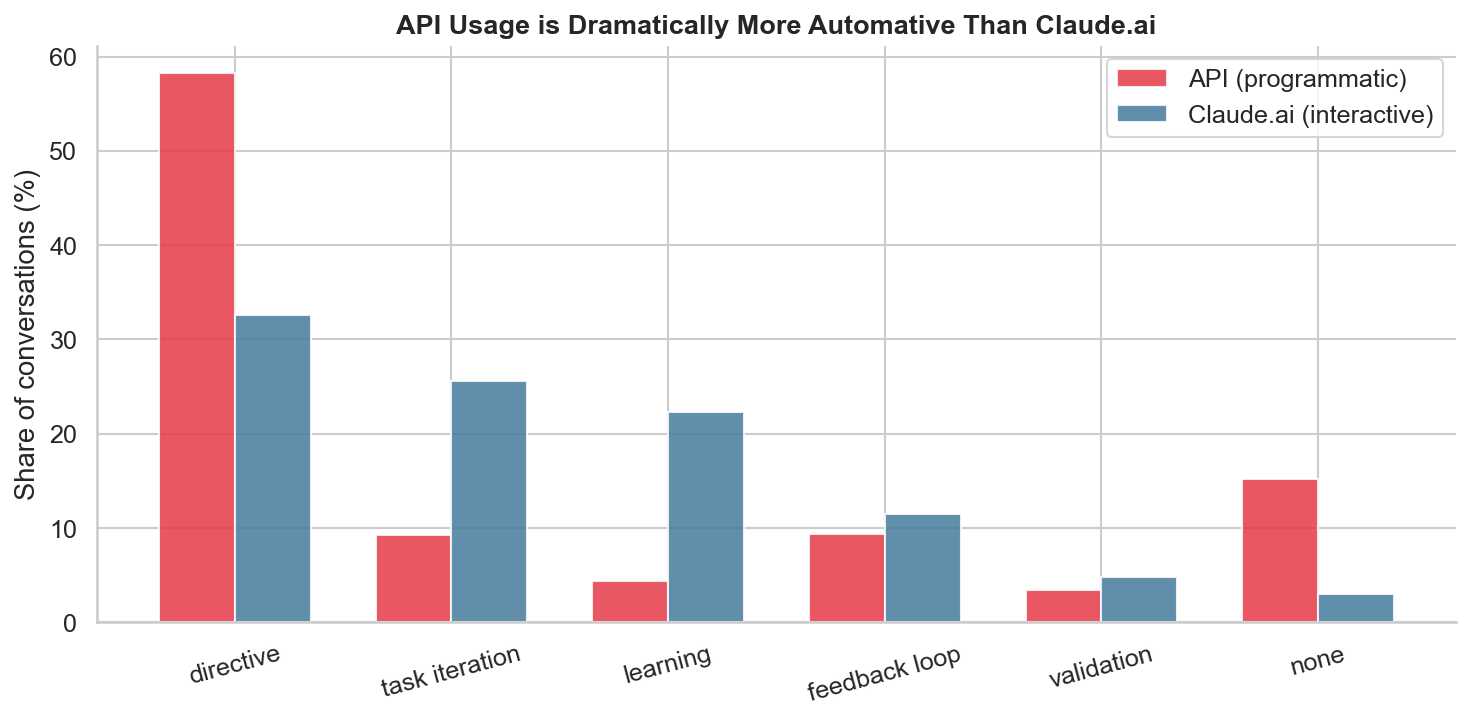


Automation-mode share (directive + feedback loop):
  API:       67.6%
  Claude.ai: 44.2%
  Gap:       +23.5pp


In [6]:
api = load_unified_release('2026_03', platform='api')
claude = load_unified_release('2026_03', platform='claude_ai')

def get_collab_breakdown(df):
    mask = (df['facet'] == 'collaboration') & (df['geography'] == 'global') & (df['variable'].str.contains('pct'))
    return df[mask].set_index('cluster_name')['value']

api_collab = get_collab_breakdown(api)
claude_collab = get_collab_breakdown(claude)

modes_order = ['directive', 'task iteration', 'learning', 'feedback loop', 'validation', 'none']
comparison = pd.DataFrame({'API': api_collab, 'Claude.ai': claude_collab}).reindex(modes_order).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comparison))
w = 0.35
ax.bar([i - w/2 for i in x], comparison['API'], w, label='API (programmatic)', color='#E63946', alpha=0.85)
ax.bar([i + w/2 for i in x], comparison['Claude.ai'], w, label='Claude.ai (interactive)', color='#457B9D', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=15)
ax.set_ylabel('Share of conversations (%)')
ax.set_title('API Usage is Dramatically More Automative Than Claude.ai',
             fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../figures/02_api_vs_claude_ai.png', bbox_inches='tight')
plt.show()

api_auto = api_collab.get('directive', 0) + api_collab.get('feedback loop', 0)
claude_auto = claude_collab.get('directive', 0) + claude_collab.get('feedback loop', 0)
print(f"\nAutomation-mode share (directive + feedback loop):")
print(f"  API:       {api_auto:.1f}%")
print(f"  Claude.ai: {claude_auto:.1f}%")
print(f"  Gap:       {api_auto - claude_auto:+.1f}pp")

---

**Key takeaways:**
1. Task coverage is sparse (median 13%) — occupation-level claims must be made carefully
2. Quality filtering is essential: 319 reliable occupations out of 633 raw
3. API usage is 68% automative vs. 44% for Claude.ai — the channel matters as much as the occupation

**Next:** [02_exploration.ipynb](02_exploration.ipynb)